# Retrieval

This notebook is made to verify the RAG retriever's model for any combination of model and index.
Change the three config variables to switch between encoders and index variants with no other edits.

**Two retrieval behaviours:**
- **Test-time** (`chunk_id=None`): sample is not in the index → return the k closest chunks directly.
- **Train-time** (`chunk_id=int`): sample IS in the index → search k+1 samples, remove the self-match by id, return k closest chunks.

## 1. Imports

Some librairies migth not being used as we modify the notebook, remove them if you like

In [1]:
import os
import json
import numpy as np
import pandas as pd
import torch
import faiss
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
from tqdm import tqdm

## 2. Configuration

In this notebook, we propose to test **one** vector-DB/retriever, choosable by changing the ``MODEL_FAMILY`` (model used to encode the vector DB), ``FINE_TUNE`` (which model ? the base one or one already fine-tuned to classify on a specific dataset) and ``INDEX_SPLIT`` (training chunks, documents chunks or both) variables.  

You can also change `K` (number of samples to retreive) and `THRESHOLD` (cosine-similarity's threshold to retreive).



In [2]:
MODEL_FAMILY = "roberta"   # "bert" | "roberta" | "hatebert"
FINE_TUNE    = "base"    # "base" | "IHC" | "ISHate" | "Vicomtech"
INDEX_SPLIT  = "training"  # "training" | "documents" | "full"

K         = 3
THRESHOLD = 0.95

In [3]:
# Do not edit
HF_IDS = {
    "bert":     "bert-base-uncased",
    "roberta":  "roberta-base",
    "hatebert": "GroNLP/hateBERT",
}
WEIGHTS_PREFIXES = {
    "bert":     "bert-base-uncased",
    "roberta":  "roberta-base",
    "hatebert": "hateBERT",
}

hf_id       = HF_IDS[MODEL_FAMILY]
index_path  = f"index/{MODEL_FAMILY}/{FINE_TUNE}/vdb_{INDEX_SPLIT}.faiss"
lookup_path = f"index/lookup_{INDEX_SPLIT}.json"
weights_path = (
    f"../weights/{WEIGHTS_PREFIXES[MODEL_FAMILY]}_{FINE_TUNE}"
    if FINE_TUNE != "base" else None
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device       : {device}")
print(f"Model family : {MODEL_FAMILY}  ({hf_id})")
print(f"Fine-tune    : {FINE_TUNE}")
print(f"Index split  : {INDEX_SPLIT}")
print(f"Index path   : {index_path}")
print(f"Weights path : {weights_path or '(HuggingFace base weights)'}")

Device       : cuda
Model family : roberta  (roberta-base)
Fine-tune    : base
Index split  : training
Index path   : index/roberta/base/vdb_training.faiss
Weights path : (HuggingFace base weights)


## 3. Load Model, Index & Documents

If `FINE_TUNE`parameter is "base", we need to load the model from HuggingFace otherwise we load it from the folder weigths.  
We load also the index from the `ìndex/` folder and the lookup table to do the masking at training-time

In [4]:
EXPECTED_MODEL_TYPES = {
    "bert":     "bert",
    "roberta":  "roberta",
    "hatebert": "bert",  # hateBERT is BERT-based architecture
}

tokenizer = AutoTokenizer.from_pretrained(hf_id)

if FINE_TUNE == "base":
    model = AutoModel.from_pretrained(hf_id)
else:
    weight_files = ["model.safetensors", "pytorch_model.bin"]
    found = [f for f in weight_files if os.path.isfile(os.path.join(weights_path, f))]
    if not found:
        raise FileNotFoundError(
            f"No model weights found in '{weights_path}'. "
            f"Expected one of {weight_files}. "
            f"Only tokenizer files are present — fine-tuned weights were never saved there."
        )
    full_model = AutoModelForSequenceClassification.from_pretrained(weights_path)
    model = full_model.base_model
    del full_model
model = model.eval().to(device)

index = faiss.read_index(index_path)
print(f"Index loaded  — {index.ntotal:,} vectors  dim={index.d}")

with open(lookup_path) as f:
    documents = json.load(f)
print(f"Lookup loaded — {len(documents):,} entries")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Index loaded  — 67,864 vectors  dim=768
Lookup loaded — 67,864 entries


## 4. Retrieval Functions



In [5]:
# The functions are now available in the `rag.py` file
from rag import encode, retrieve_top_k, retrieve_by_threshold, retrieve_top_k_above_threshold

## 5. Validation — Test-time Behaviour

Queries without a `chunk_id` (simulating the test set, where tweets are not in the index).
Expected:
- Hate tweets → hateful, semantically relevant neighbors.
- "i dont like tomatoes" → weak, unrelated neighbors (low semantic match).
- "i dont like neggers" → hateful neighbors.

In [6]:
test_queries = [
    ("HATE",     "jews are now in full control : canadian man goes to jail for posting on white nationalist websites"),
    ("HATE",     "i dont like neggers"),
    ("NOT HATE", "i dont like tomatoes"),
    ("NOT HATE", "Charges in deadly wreck that killed 5 motorcyclists . Crash takes injured woman s fiance , mom ."),
]

sep = "=" * 70

for label, tweet in test_queries:
    print(f"\n{sep}")
    print(f"[{label}] {tweet}")

    print(f"  -- retrieve_top_k (k={K}) --")
    for text, score in retrieve_top_k(tweet, model, tokenizer, index, documents):
        print(f"    {score:.4f}  {text[:90]}")

    # Uncomment to test retrieve_by_threshold (can return hundreds of results):
    # print(f"  -- retrieve_by_threshold (threshold={THRESHOLD}) --")
    # hits = retrieve_by_threshold(tweet, THRESHOLD, model, tokenizer, index, documents)
    # for text, score in hits or []:
    #     print(f"    {score:.4f}  {text[:90]}")
    # if not hits:
    #     print("    (no results above threshold)")

    print(f"  -- retrieve_top_k_above_threshold (threshold={THRESHOLD}, k=10) --")
    hits = retrieve_top_k_above_threshold(tweet, THRESHOLD, model, tokenizer, index, documents, k=10)
    if hits:
        for text, score in hits:
            print(f"    {score:.4f}  {text[:90]}")
    else:
        print("    (no results above threshold)")


[HATE] jews are now in full control : canadian man goes to jail for posting on white nationalist websites
  -- retrieve_top_k (k=3) --


Encoding:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding: 100%|██████████| 1/1 [00:00<00:00,  7.03it/s]

Encoding: 100%|██████████| 1/1 [00:00<00:00,  6.97it/s]

    0.9995  [hate] : jews are now in full control : canadian man goes to jail for posting on white nat
    0.9993  [not hate] jews are now in full control : canadian man goes to jail for posting on white n
    0.9993  [hate] jews are now in full control : canadian man goes to jail for posting on white natio
    0.9989  [hate] : black activists call for lynching and hanging of white people and cops
  -- retrieve_top_k_above_threshold (threshold=0.95, k=10) --


...

Encoding: 100%|██████████| 1/1 [00:00<00:00, 127.44it/s]

    0.9981  [not hate] : germany : muslim migrant deliberately rams car into revellers outside disco  
    0.9980  [not hate] Jackson 's retrial took jurors back to the events of late summer 1977 , when tw
    0.9980  [not hate] hate crime charge dropped for 4 black teens who kidnapped and tortured a white 
    0.9979  [not hate] sure . it's a big conspiracy . of course it is .
  -- retrieve_top_k_above_threshold (threshold=0.95, k=10) --


Encoding:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding: 100%|██████████| 1/1 [00:00<00:00, 86.21it/s]

    0.9981  [not hate] : germany : muslim migrant deliberately rams car into revellers outside disco  
    0.9980  [not hate] Jackson 's retrial took jurors back to the events of late summer 1977 , when tw
    0.9980  [not hate] hate crime charge dropped for 4 black teens who kidnapped and tortured a white 
    0.9979  [not hate] sure . it's a big conspiracy . of course it is .
    0.9979  [not hate] not racist  just retarded .
    0.9979  [not hate] now that's racist . you should be ashamed .
    0.9979  [not hate] Steve Reed Reporter Three of the suspects charged with the murder of a 12-year 
    0.9979  [not hate] it's odd that he would tap his brakes at that point  if his desire was to run p
    0.9979  [hate] muslim refugees  thats what happened . dirty pigs ..
    0.9979  [not hate] He allegedly grabbed a knife from the home s kitchen and ended up stabbing Enge


## 6. Validation — Train-time Self-exclusion

Only meaningful when `INDEX_SPLIT == "training"` (tweets are in the index).

For 3 randomly sampled training tweets, verify that:
1. The tweet's own text does **not** appear in the retrieved neighbors when `chunk_id` is passed.
2. It **does** appear (as the top result) when `chunk_id=None` is passed — confirming it was in the index.

In [7]:
if INDEX_SPLIT != "training":
    print(f"Skipping self-exclusion check — INDEX_SPLIT='{INDEX_SPLIT}' (tweets not in this index).")
else:
    df = pd.read_csv("chunks/chunks_training.csv")

    def strip_prefix(text):
        return text.replace("[hate] ", "", 1).replace("[not hate] ", "", 1)

    sample = df.sample(3, random_state=42)

    for _, row in sample.iterrows():
        raw = strip_prefix(row.text)
        cid = int(row.chunk_id)

        without_exclusion = retrieve_top_k(raw, model, tokenizer, index, documents, chunk_id=None, k=K + 1)
        with_exclusion    = retrieve_top_k(raw, model, tokenizer, index, documents, chunk_id=cid,  k=K)

        self_in_without = any(text == row.text for text, _ in without_exclusion)
        self_in_with    = any(text == row.text for text, _ in with_exclusion)

        print("\n" + "=" * 70)
        print(f"chunk_id={cid}  |  {raw[:80]}")
        print(f"  Self present WITHOUT exclusion : {self_in_without}  (expected True)")
        print(f"  Self present WITH    exclusion : {self_in_with}   (expected False)")
        assert self_in_without, f"chunk_id={cid} not found in index — check index"
        assert not self_in_with, f"Self-exclusion failed for chunk_id={cid}"

    print("\nAll self-exclusion checks passed.")

Encoding:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding: 100%|██████████| 1/1 [00:00<00:00, 142.18it/s]

Encoding:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding: 100%|██████████| 1/1 [00:00<00:00, 131.49it/s]


chunk_id=2909  |  pl . note trump is not racist  this is false propaganda of opponents
  Self present WITHOUT exclusion : True  (expected True)
  Self present WITH    exclusion : False   (expected False)


...

Encoding:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding: 100%|██████████| 1/1 [00:00<00:00, 147.74it/s]

Encoding:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding: 100%|██████████| 1/1 [00:00<00:00, 151.66it/s]


chunk_id=57254  |  "in our heavily populated cities , with their fancy stores and restaurants , we 
  Self present WITHOUT exclusion : True  (expected True)
  Self present WITH    exclusion : False   (expected False)

All self-exclusion checks passed.


## 7. Vector-Space Analysis

Metrics that characterise the geometry of the embedding space created by this model/index pair.
All metrics are computed on a random sample of `N_SAMPLE` vectors drawn from the index.

| Metric | Interpretation |
|---|---|
| **Effective rank** | How many dimensions carry meaningful variance (higher = richer space) |
| **Mean pairwise cosine similarity** | Isotropy: lower means vectors are well spread across the sphere |
| **Cosine similarity distribution** | Shape of the similarity landscape |
| **Norm statistics** (before L2-norm) | Whether the model collapses embeddings to similar magnitudes |
| **Intra- vs inter-class similarity** | Whether hate/not-hate form geometrically separated clusters |

Encoding 2000 random samples...


Encoding:   0%|          | 0/32 [00:00<?, ?it/s]

Encoding:   6%|▋         | 2/32 [00:00<00:02, 14.68it/s]

Encoding:  12%|█▎        | 4/32 [00:00<00:01, 16.95it/s]

Encoding:  19%|█▉        | 6/32 [00:00<00:01, 17.88it/s]

...

Encoding:  84%|████████▍ | 27/32 [00:01<00:00, 20.22it/s]

Encoding:  94%|█████████▍| 30/32 [00:01<00:00, 20.06it/s]

Encoding: 100%|██████████| 32/32 [00:01<00:00, 19.59it/s]


── Norm statistics (pre-normalisation) ──
  mean : 11.1131
  std  : 0.2352
  min  : 10.7214   max : 12.4615



── Effective rank ──
  Effective rank : 391.8  /  768  dimensions

── Pairwise cosine similarity ──
  mean : 0.9970   std : 0.0013
  → High anisotropy — vectors cluster tightly


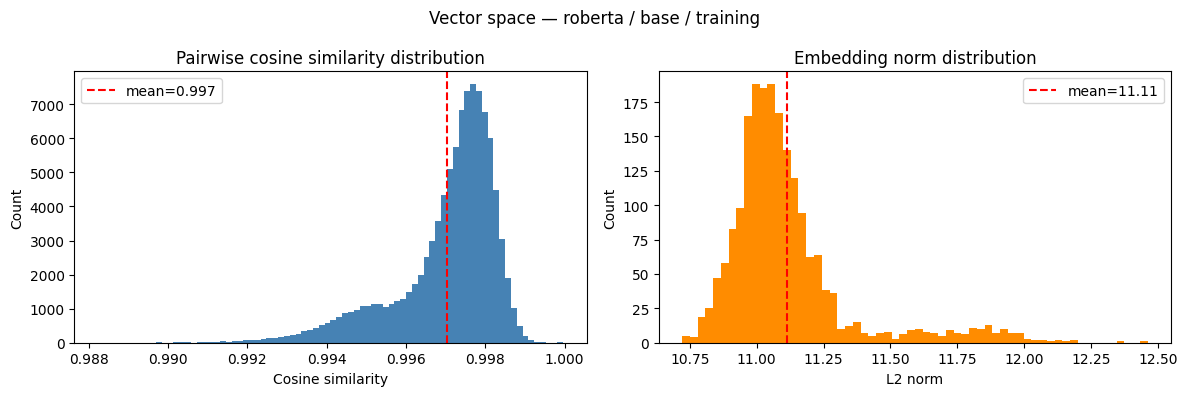


── Intra- vs inter-class cosine similarity ──
  hate    ↔ hate    (intra) : 0.9970
  nothate ↔ nothate (intra) : 0.9973
  hate    ↔ nothate (inter) : 0.9970
  Separation gap (intra_mean − inter) : 0.0002  ← classes overlap


In [8]:
N_SAMPLE = 2000  # number of random vectors to draw from the index

# ── Sample raw (un-normalised) vectors from the index ────────────────────────
# IndexIDMap wraps IndexFlatIP; reconstruct gives L2-normalised vectors since
# we normalised before adding. We re-encode a random sample from the lookup to
# get the raw (pre-norm) norms as well.
rng = np.random.default_rng(0)
all_ids = list(documents.keys())
sample_ids = rng.choice(all_ids, size=min(N_SAMPLE, len(all_ids)), replace=False)
sample_texts = [documents[sid] for sid in sample_ids]

print(f"Encoding {len(sample_texts)} random samples...")
raw_vecs = encode(sample_texts, model, tokenizer)   # shape (N, D), un-normalised

# ── 1. Norm statistics ────────────────────────────────────────────────────────
norms = np.linalg.norm(raw_vecs, axis=1)
print(f"\n── Norm statistics (pre-normalisation) ──")
print(f"  mean : {norms.mean():.4f}")
print(f"  std  : {norms.std():.4f}")
print(f"  min  : {norms.min():.4f}   max : {norms.max():.4f}")

# ── 2. Effective rank ─────────────────────────────────────────────────────────
# Effective rank = exp(entropy of normalised singular value distribution).
# Ranges from 1 (rank-1 collapse) to D (full use of all dimensions).
centered = raw_vecs - raw_vecs.mean(axis=0)
_, sv, _ = np.linalg.svd(centered, full_matrices=False)
sv_norm = sv / sv.sum()
entropy = -np.sum(sv_norm * np.log(sv_norm + 1e-12))
eff_rank = np.exp(entropy)
print(f"\n── Effective rank ──")
print(f"  Effective rank : {eff_rank:.1f}  /  {raw_vecs.shape[1]}  dimensions")

# ── 3. Mean pairwise cosine similarity (isotropy) ─────────────────────────────
normed = raw_vecs / (norms[:, None] + 1e-12)
# Compute all pairwise cosines via matrix multiply; exclude self-pairs
cos_matrix = normed @ normed.T
np.fill_diagonal(cos_matrix, np.nan)
pairwise = cos_matrix[~np.isnan(cos_matrix)]
mean_cos = np.nanmean(pairwise)
std_cos  = np.nanstd(pairwise)
print(f"\n── Pairwise cosine similarity ──")
print(f"  mean : {mean_cos:.4f}   std : {std_cos:.4f}")
print(f"  → {'High anisotropy — vectors cluster tightly' if mean_cos > 0.95 else 'Good spread across the sphere' if mean_cos < 0.85 else 'Moderate spread'}")

# ── 4. Cosine similarity distribution (histogram) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"Vector space — {MODEL_FAMILY} / {FINE_TUNE} / {INDEX_SPLIT}")

# Subsample pairs to keep the histogram manageable
pair_sample = rng.choice(pairwise, size=min(100_000, len(pairwise)), replace=False)
axes[0].hist(pair_sample, bins=80, color="steelblue", edgecolor="none")
axes[0].axvline(mean_cos, color="red", linestyle="--", label=f"mean={mean_cos:.3f}")
axes[0].set_xlabel("Cosine similarity")
axes[0].set_ylabel("Count")
axes[0].set_title("Pairwise cosine similarity distribution")
axes[0].legend()

axes[1].hist(norms, bins=60, color="darkorange", edgecolor="none")
axes[1].axvline(norms.mean(), color="red", linestyle="--", label=f"mean={norms.mean():.2f}")
axes[1].set_xlabel("L2 norm")
axes[1].set_ylabel("Count")
axes[1].set_title("Embedding norm distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

# ── 5. Intra- vs inter-class similarity ──────────────────────────────────────
hate_mask    = np.array([documents[sid].startswith("[hate]")     for sid in sample_ids])
nothate_mask = np.array([documents[sid].startswith("[not hate]") for sid in sample_ids])

def mean_block_similarity(mask_a, mask_b, cos_mat):
    block = cos_mat[np.ix_(mask_a, mask_b)]
    if mask_a is mask_b:
        np.fill_diagonal(block, np.nan)
    return np.nanmean(block)

if hate_mask.sum() > 1 and nothate_mask.sum() > 1:
    intra_hate    = mean_block_similarity(hate_mask, hate_mask, cos_matrix)
    intra_nothate = mean_block_similarity(nothate_mask, nothate_mask, cos_matrix)
    inter         = mean_block_similarity(hate_mask, nothate_mask, cos_matrix)
    print(f"\n── Intra- vs inter-class cosine similarity ──")
    print(f"  hate    ↔ hate    (intra) : {intra_hate:.4f}")
    print(f"  nothate ↔ nothate (intra) : {intra_nothate:.4f}")
    print(f"  hate    ↔ nothate (inter) : {inter:.4f}")
    sep_ratio = ((intra_hate + intra_nothate) / 2 - inter)
    print(f"  Separation gap (intra_mean − inter) : {sep_ratio:.4f}  {'← good separation' if sep_ratio > 0.01 else '← classes overlap'}")
else:
    print("\n(Not enough labelled samples to compute intra/inter-class similarity)")

## 8. Cross-Index Comparison

Metrics across **all 36 combinations** (3 families × 4 variants × 3 splits).
Vectors are reconstructed directly from each FAISS index — no model loading needed.

| Metric | Note |
|---|---|
| **Effective rank** | Computed on normalised vectors — reflects dimensional usage |
| **Isotropy** | Mean pairwise cosine similarity — lower = better spread |
| **Separation gap** | Mean intra-class sim − mean inter-class sim — higher = better |

In [9]:
from pathlib import Path

ALL_FAMILIES  = ["bert", "roberta", "hatebert"]
ALL_VARIANTS  = ["base", "IHC", "ISHate", "Vicomtech"]
ALL_SPLITS    = ["training", "documents", "full"]
N_SAMPLE_CMP  = 500

rng_cmp      = np.random.default_rng(42)
lookup_cache = {}
records      = []
n_failed     = 0

def _block_sim(cos_mat, mask_a, mask_b, diagonal_nan=False):
    block = cos_mat[np.ix_(mask_a, mask_b)].copy()
    if diagonal_nan:
        np.fill_diagonal(block, np.nan)
    return float(np.nanmean(block))

for family in ALL_FAMILIES:
    for variant in ALL_VARIANTS:
        for split in ALL_SPLITS:
            idx_path = Path(f"index/{family}/{variant}/vdb_{split}.faiss")
            if not idx_path.exists():
                print(f"  Missing: {idx_path}")
                n_failed += 1
                continue

            if split not in lookup_cache:
                with open(f"index/lookup_{split}.json") as f:
                    lookup_cache[split] = json.load(f)
            lookup = lookup_cache[split]

            idx = faiss.read_index(str(idx_path))

            # Reconstruct via the underlying flat index (IndexIDMap.reconstruct by external ID
            # is unreliable across FAISS versions). Use id_map to recover external IDs for
            # the label lookup.
            try:
                id_map      = faiss.vector_to_array(idx.id_map)
                inner       = faiss.downcast_index(idx.index)
                sample_pos  = rng_cmp.choice(idx.ntotal, size=min(N_SAMPLE_CMP, idx.ntotal), replace=False)
                vecs        = np.stack([inner.reconstruct(int(p)) for p in sample_pos])
                sample_cids = [str(id_map[p]) for p in sample_pos]
            except Exception as e:
                print(f"  [{family}/{variant}/{split}] reconstruct failed: {e}")
                n_failed += 1
                continue

            # Effective rank (on normalised vectors)
            centered = vecs - vecs.mean(axis=0)
            _, sv, _ = np.linalg.svd(centered, full_matrices=False)
            sv_norm  = sv / sv.sum()
            eff_rank = float(np.exp(-np.sum(sv_norm * np.log(sv_norm + 1e-12))))

            # Isotropy — mean pairwise cosine (vectors already unit-norm)
            cos_mat = vecs @ vecs.T
            np.fill_diagonal(cos_mat, np.nan)
            isotropy = float(np.nanmean(cos_mat))

            # Intra / inter-class separation
            hate_mask    = np.array([lookup[cid].startswith("[hate]")     for cid in sample_cids])
            nothate_mask = np.array([lookup[cid].startswith("[not hate]") for cid in sample_cids])
            sep_gap = None
            if hate_mask.sum() > 1 and nothate_mask.sum() > 1:
                intra = (_block_sim(cos_mat, hate_mask, hate_mask, diagonal_nan=True) +
                         _block_sim(cos_mat, nothate_mask, nothate_mask, diagonal_nan=True)) / 2
                inter = _block_sim(cos_mat, hate_mask, nothate_mask)
                sep_gap = intra - inter

            records.append({
                "family":   family,
                "variant":  variant,
                "split":    split,
                "eff_rank": eff_rank,
                "isotropy": isotropy,
                "sep_gap":  sep_gap,
            })
            print(f"  [{family:8s}/{variant:10s}/{split:9s}]  "
                  f"eff_rank={eff_rank:6.1f}  "
                  f"isotropy={isotropy:.4f}  "
                  f"sep_gap={sep_gap:.4f}" if sep_gap is not None else
                  f"  [{family:8s}/{variant:10s}/{split:9s}]  "
                  f"eff_rank={eff_rank:6.1f}  "
                  f"isotropy={isotropy:.4f}  sep_gap=N/A")

df_cmp = pd.DataFrame(records)
print(f"\nCollected {len(df_cmp)} / 36 configurations  ({n_failed} failed)")
if df_cmp.empty:
    raise RuntimeError("No configurations collected — check 'reconstruct failed' lines above")

  [bert    /base      /training ]  eff_rank= 308.4  isotropy=0.8232  sep_gap=0.0094


  [bert    /base      /documents]  eff_rank= 332.9  isotropy=0.8129  sep_gap=N/A


  [bert    /base      /full     ]  eff_rank= 323.3  isotropy=0.8109  sep_gap=0.0071


  [bert    /IHC       /training ]  eff_rank= 288.0  isotropy=0.3265  sep_gap=0.1760


  [bert    /IHC       /documents]  eff_rank= 300.5  isotropy=0.4056  sep_gap=N/A


...

  [hatebert/ISHate    /documents]  eff_rank= 326.8  isotropy=0.4215  sep_gap=N/A


  [hatebert/ISHate    /full     ]  eff_rank= 295.8  isotropy=0.1637  sep_gap=0.2054


  [hatebert/Vicomtech /training ]  eff_rank= 318.2  isotropy=0.3664  sep_gap=0.1112


  [hatebert/Vicomtech /documents]  eff_rank= 324.7  isotropy=0.5118  sep_gap=N/A


  [hatebert/Vicomtech /full     ]  eff_rank= 323.3  isotropy=0.3593  sep_gap=0.0282

Collected 36 / 36 configurations  (0 failed)


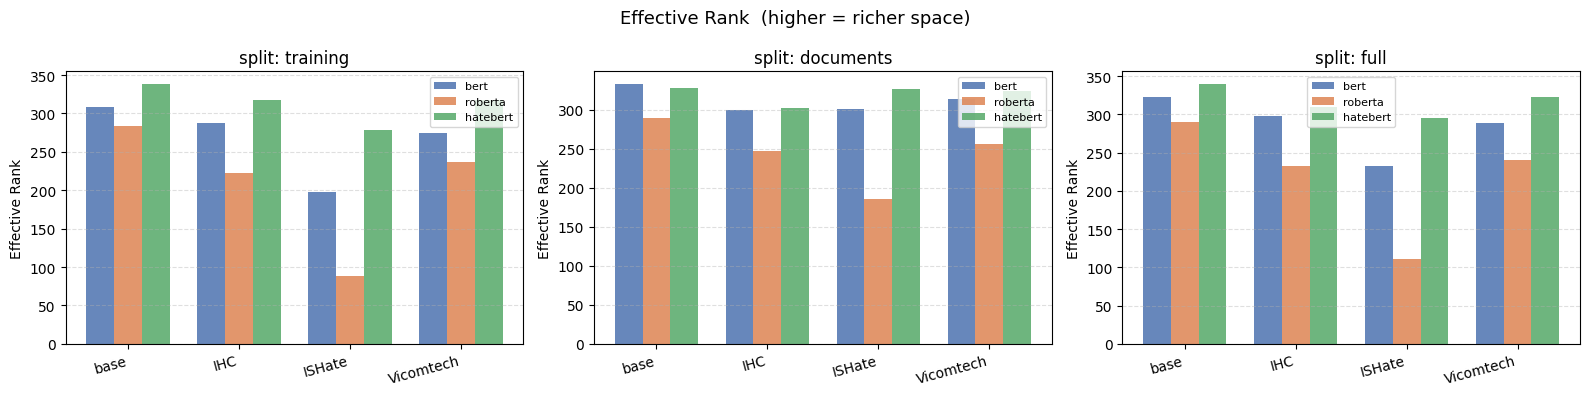

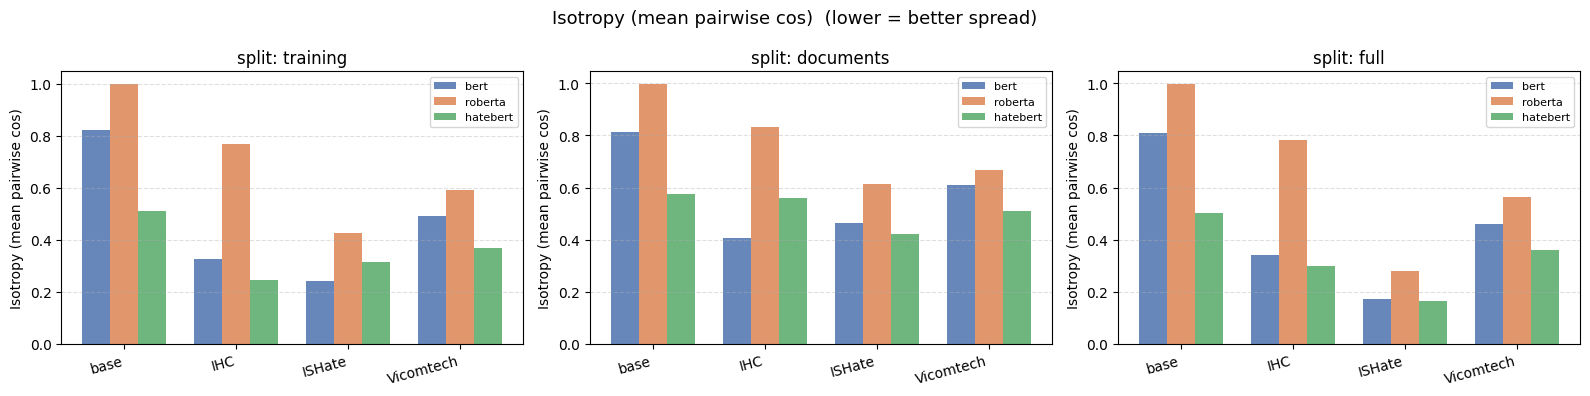

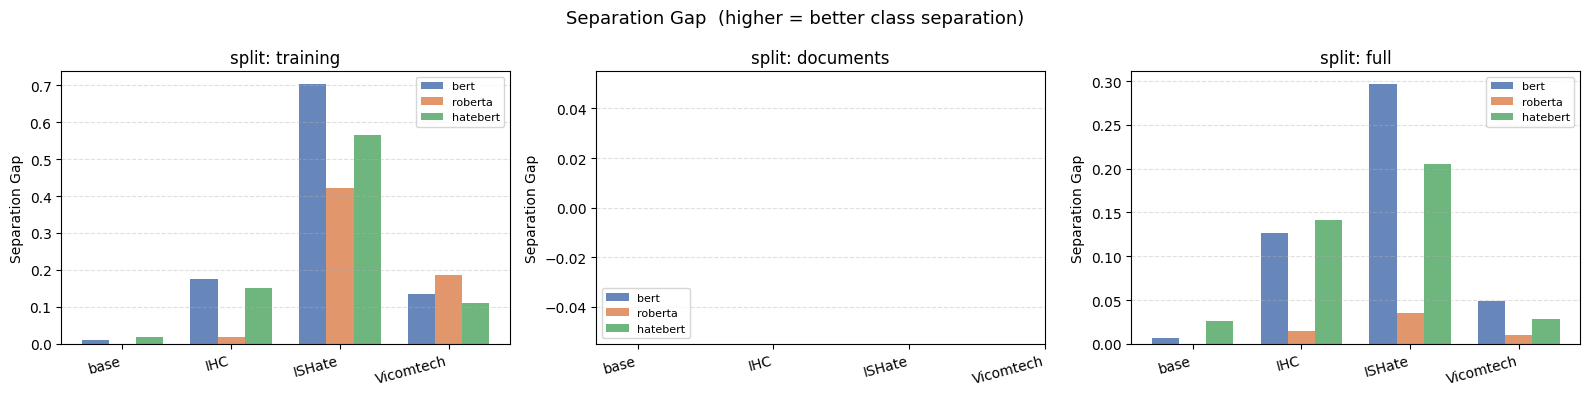

In [10]:
if df_cmp.empty:
    raise RuntimeError("df_cmp is empty — re-run the previous cell to diagnose")

metrics_to_plot = [
    ("eff_rank", "Effective Rank",              "higher = richer space"),
    ("isotropy", "Isotropy (mean pairwise cos)","lower = better spread"),
    ("sep_gap",  "Separation Gap",              "higher = better class separation"),
]

colors = {"bert": "#4c72b0", "roberta": "#dd8452", "hatebert": "#55a868"}
x      = np.arange(len(ALL_VARIANTS))
width  = 0.25

for metric_key, metric_label, metric_desc in metrics_to_plot:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
    fig.suptitle(f"{metric_label}  ({metric_desc})", fontsize=13)

    for ax, split in zip(axes, ALL_SPLITS):
        df_s = df_cmp[df_cmp["split"] == split]

        for i, family in enumerate(ALL_FAMILIES):
            df_f = df_s[df_s["family"] == family]
            vals = []
            for v in ALL_VARIANTS:
                row = df_f[df_f["variant"] == v]
                vals.append(float(row[metric_key].iloc[0]) if len(row) and row[metric_key].iloc[0] is not None else np.nan)

            bars = ax.bar(x + i * width, vals, width,
                          label=family, color=colors[family], alpha=0.85)

        ax.set_title(f"split: {split}")
        ax.set_xticks(x + width)
        ax.set_xticklabels(ALL_VARIANTS, rotation=15, ha="right")
        ax.set_ylabel(metric_label)
        ax.legend(fontsize=8)
        ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()